<H1> Exploratory Data Analysis Project Using SQLite</H1>

E-Commerce Data from the UCI Machine Learning Repository 

This dataset contains data containing real transactions made from 1/12/2010 to 9/12/2011 for an online retail store. 

In [47]:
#Import Necessary Libraries
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [32]:
#Load the dataset in to a database
df = pd.read_csv('/Users/Ryan/Code/Portfolio/data.csv', header = 1)
conn = sqlite3.connect('data.db')
df.to_sql('data', conn, if_exists='replace', index=False)
conn.close()

<H2> Explore the Data </H2>

In [33]:
#Load first 10 lines to ensure data is loaded correctly
conn = sqlite3.connect('data.db')
sql_head = """
SELECT *
FROM data
LIMIT 10;"""

sql_header = pd.read_sql_query(sql_head, conn)
conn.close()
print(sql_header)

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
5    536365     22752         SET 7 BABUSHKA NESTING BOXES         2   
6    536365     21730    GLASS STAR FROSTED T-LIGHT HOLDER         6   
7    536366     22633               HAND WARMER UNION JACK         6   
8    536366     22632            HAND WARMER RED POLKA DOT         6   
9    536367     84879        ASSORTED COLOUR BIRD ORNAMENT        32   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75  

In [ ]:
#Check Table Info
conn = sqlite3.connect('data.db')
sql_query = """
PRAGMA table_info(data);
"""

sql = pd.read_sql_query(sql_query, conn)
conn.close()
print(sql)

   cid         name     type  notnull dflt_value  pk
0    0    InvoiceNo     TEXT        0       None   0
1    1    StockCode     TEXT        0       None   0
2    2  Description     TEXT        0       None   0
3    3     Quantity  INTEGER        0       None   0
4    4  InvoiceDate     TEXT        0       None   0
5    5    UnitPrice     REAL        0       None   0
6    6   CustomerID     REAL        0       None   0
7    7      Country     TEXT        0       None   0


The dataset primarily has text data types. The quantity is the only integer due to letter number combinations in the InvoiceNo and StockCode.  The Unit Price and CustomerID are real due to having decimals. 

In [ ]:
#Check For Nulls 
conn = sqlite3.connect('data.db')
sql_query = """
SELECT COUNT(*) AS Count_CustomerID_ISNULL
FROM Data
WHERE CustomerID IS NULL;
"""

sql = pd.read_sql_query(sql_query, conn)
conn.close()
print(sql)

   Count_CustomerID_ISNULL
0                   135080


There are a lot of customers that order without a customerID this is likely due to guest checkouts and new orders. 

In [ ]:
#Check to see what countries have ordered
conn = sqlite3.connect('data.db')
sql_query = """
SELECT DISTINCT(Country) 
FROM data
ORDER BY Country ASC;"""

sql = pd.read_sql_query(sql_query, conn)
conn.close()
print(sql)

                 Country
0              Australia
1                Austria
2                Bahrain
3                Belgium
4                 Brazil
5                 Canada
6        Channel Islands
7                 Cyprus
8         Czech Republic
9                Denmark
10                  EIRE
11    European Community
12               Finland
13                France
14               Germany
15                Greece
16             Hong Kong
17               Iceland
18                Israel
19                 Italy
20                 Japan
21               Lebanon
22             Lithuania
23                 Malta
24           Netherlands
25                Norway
26                Poland
27              Portugal
28                   RSA
29          Saudi Arabia
30             Singapore
31                 Spain
32                Sweden
33           Switzerland
34                   USA
35  United Arab Emirates
36        United Kingdom
37           Unspecified


The company has orders from all around the world. 

In [ ]:
#Top 10 Countries Based on Sales
conn = sqlite3.connect('data.db')
sql_query = """
SELECT Country, SUM(Quantity * UnitPrice) AS CountrySales
FROM data 
GROUP BY Country 
ORDER BY CountrySales DESC
LIMIT 10; 
"""

sql = pd.read_sql_query(sql_query, conn)
conn.close()
print(sql)

          Country  CountrySales
0  United Kingdom  8.187806e+06
1     Netherlands  2.846615e+05
2            EIRE  2.632768e+05
3         Germany  2.216982e+05
4          France  1.974039e+05
5       Australia  1.370773e+05
6     Switzerland  5.638535e+04
7           Spain  5.477458e+04
8         Belgium  4.091096e+04
9          Sweden  3.659591e+04


Company is mainly selling to countries in Europe with the largest portion of their sales coming from the UK. 

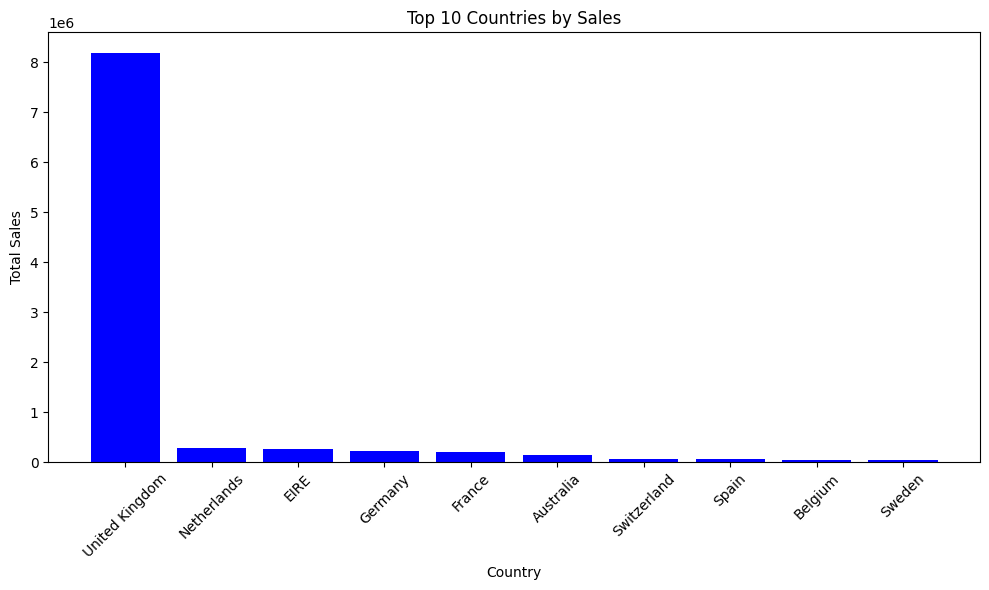

In [55]:
# Connect and query
conn = sqlite3.connect('data.db')
sql_query = """
SELECT Country, SUM(Quantity * UnitPrice) AS CountrySales
FROM data 
GROUP BY Country 
ORDER BY CountrySales DESC
LIMIT 10; 
"""
sql = pd.read_sql_query(sql_query, conn)
conn.close()

# Plot
plt.figure(figsize=(10,6))
plt.bar(sql['Country'], sql['CountrySales'], color='blue')
plt.title("Top 10 Countries by Sales")
plt.xlabel("Country")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




In [ ]:
#See 10 largest orders based on total
conn = sqlite3.connect('data.db')
sql_query = """
SELECT InvoiceNo, Quantity, UnitPrice, Quantity * UnitPrice AS Total
FROM data
ORDER BY Total DESC
LIMIT 10;
"""

sql = pd.read_sql_query(sql_query, conn)
conn.close()
print(sql)

  InvoiceNo  Quantity  UnitPrice      Total
0    581483     80995       2.08  168469.60
1    541431     74215       1.04   77183.60
2    556444        60     649.50   38970.00
3    537632         1   13541.33   13541.33
4   A563185         1   11062.06   11062.06
5    551697         1    8142.75    8142.75
6    567423      1412       5.06    7144.72
7    540815      3114       2.10    6539.40
8    550461      3114       2.10    6539.40
9    573003      2400       2.08    4992.00


The largest orders are extremely outside of the normal order total. 

In [66]:
#See if the large orders were a mistake
#Get the customer id and the invoice dates
conn = sqlite3.connect('data.db')
sql_query = """
SELECT *
FROM data
WHERE InvoiceNo = 581483;
"""

sql = pd.read_sql_query(sql_query, conn)
conn.close()
print(sql)

conn = sqlite3.connect('data.db')
sql_query = """
SELECT *
FROM data
WHERE InvoiceNo = 541431;
"""

sql = pd.read_sql_query(sql_query, conn)
conn.close()
print(sql)

  InvoiceNo StockCode                  Description  Quantity     InvoiceDate  \
0    581483     23843  PAPER CRAFT , LITTLE BIRDIE     80995  12/9/2011 9:15   

   UnitPrice  CustomerID         Country  
0       2.08     16446.0  United Kingdom  
  InvoiceNo StockCode                     Description  Quantity  \
0    541431     23166  MEDIUM CERAMIC TOP STORAGE JAR     74215   

       InvoiceDate  UnitPrice  CustomerID         Country  
0  1/18/2011 10:01       1.04     12346.0  United Kingdom  


In [ ]:
#See if they reversed the orders on the same day
#Check CustomerID 12346.0
conn = sqlite3.connect('data.db')
sql_query = """
SELECT *
FROM data
WHERE CustomerID = 12346.0
AND InvoiceDate LIKE '1/18/2011%'
"""

sql = pd.read_sql_query(sql_query, conn)
conn.close()
print(sql)

  InvoiceNo StockCode                     Description  Quantity  \
0    541431     23166  MEDIUM CERAMIC TOP STORAGE JAR     74215   
1   C541433     23166  MEDIUM CERAMIC TOP STORAGE JAR    -74215   

       InvoiceDate  UnitPrice  CustomerID         Country  
0  1/18/2011 10:01       1.04     12346.0  United Kingdom  
1  1/18/2011 10:17       1.04     12346.0  United Kingdom  


In [64]:
#See if they reversed the orders on the same day
#Check CustomerID 16446.0
conn = sqlite3.connect('data.db')
sql_query = """
SELECT *
FROM data
WHERE CustomerID = 16446.0
AND InvoiceDate LIKE '12/9/2011%'
"""

sql = pd.read_sql_query(sql_query, conn)
conn.close()
print(sql)

  InvoiceNo StockCode                  Description  Quantity     InvoiceDate  \
0    581483     23843  PAPER CRAFT , LITTLE BIRDIE     80995  12/9/2011 9:15   
1   C581484     23843  PAPER CRAFT , LITTLE BIRDIE    -80995  12/9/2011 9:27   

   UnitPrice  CustomerID         Country  
0       2.08     16446.0  United Kingdom  
1       2.08     16446.0  United Kingdom  


Both orders were reversed on the same day. This means they were likely mistakes. 

                          Description      Total
0                      DOTCOM POSTAGE  206245.48
1            REGENCY CAKESTAND 3 TIER  164762.19
2  WHITE HANGING HEART T-LIGHT HOLDER   99668.47
3                       PARTY BUNTING   98302.98
4             JUMBO BAG RED RETROSPOT   92356.03
5                  RABBIT NIGHT LIGHT   66756.59
6                             POSTAGE   66230.64
7      PAPER CHAIN KIT 50'S CHRISTMAS   63791.94
8       ASSORTED COLOUR BIRD ORNAMENT   58959.73
9                       CHILLI LIGHTS   53768.06


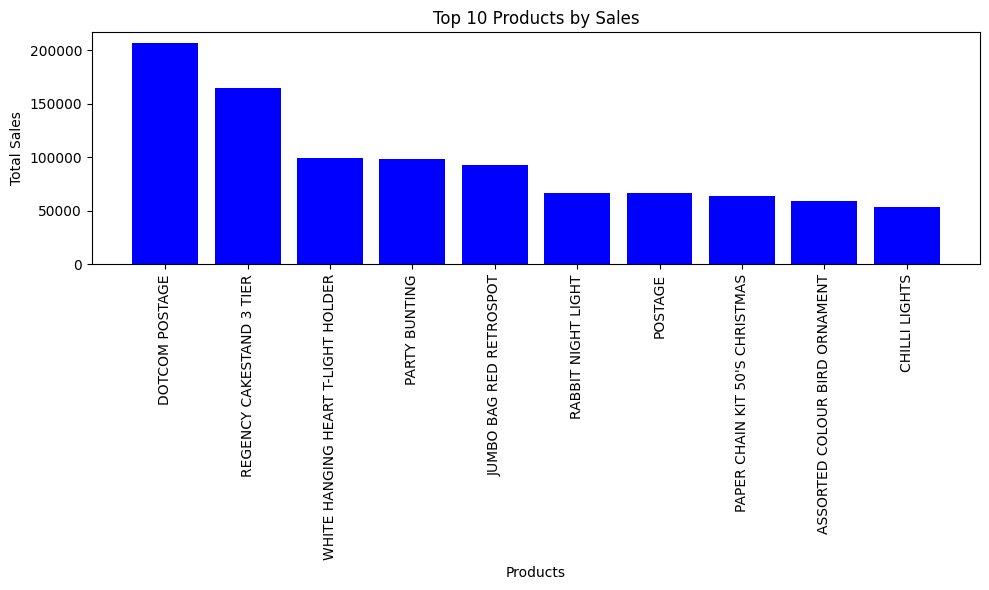

In [69]:
#Top 10 Products Based on Sales
conn = sqlite3.connect('data.db')
sql_query = """
SELECT Description, SUM(Quantity * UnitPrice) AS Total
FROM data 
GROUP BY Description 
ORDER BY Total DESC
LIMIT 10; 
"""

sql = pd.read_sql_query(sql_query, conn)
conn.close()
print(sql)

# Plot
plt.figure(figsize=(10,6))
plt.bar(sql['Description'], sql['Total'], color='blue')
plt.title("Top 10 Products by Sales")
plt.xlabel("Products")
plt.ylabel("Total Sales")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


The best selling prodcuts were the DotCom Postage and the Regency Cakestand 3 Tier

In [75]:
#Top 10 Customers Based on Sales
conn = sqlite3.connect('data.db')
sql_query = """
SELECT 
    CustomerID,
    SUM(Quantity * UnitPrice) AS Total,
    (SUM(Quantity * UnitPrice) * 100.0 / (SELECT SUM(Quantity * UnitPrice) FROM data)) AS Percentage_of_Sales
FROM data
GROUP BY CustomerID
ORDER BY Total DESC
LIMIT 10;
"""

sql = pd.read_sql_query(sql_query, conn)
conn.close()
print(sql)


   CustomerID       Total  Percentage_of_Sales
0         NaN  1447682.12            14.851452
1     14646.0   279489.02             2.867216
2     18102.0   256438.49             2.630746
3     17450.0   187482.17             1.923338
4     14911.0   132572.62             1.360033
5     12415.0   123725.45             1.269272
6     14156.0   113384.14             1.163183
7     17511.0    88125.38             0.904059
8     16684.0    65892.08             0.675972
9     13694.0    62653.10             0.642744


Most of the customers orders did not include a customer id meaning they were either new customers or the company did not input the data correctly.  

The top customer made up on 2.86% of the sales meaning that the company has a diverse client base. 